Saved → ../data/bangladesh_earthquake_map.png


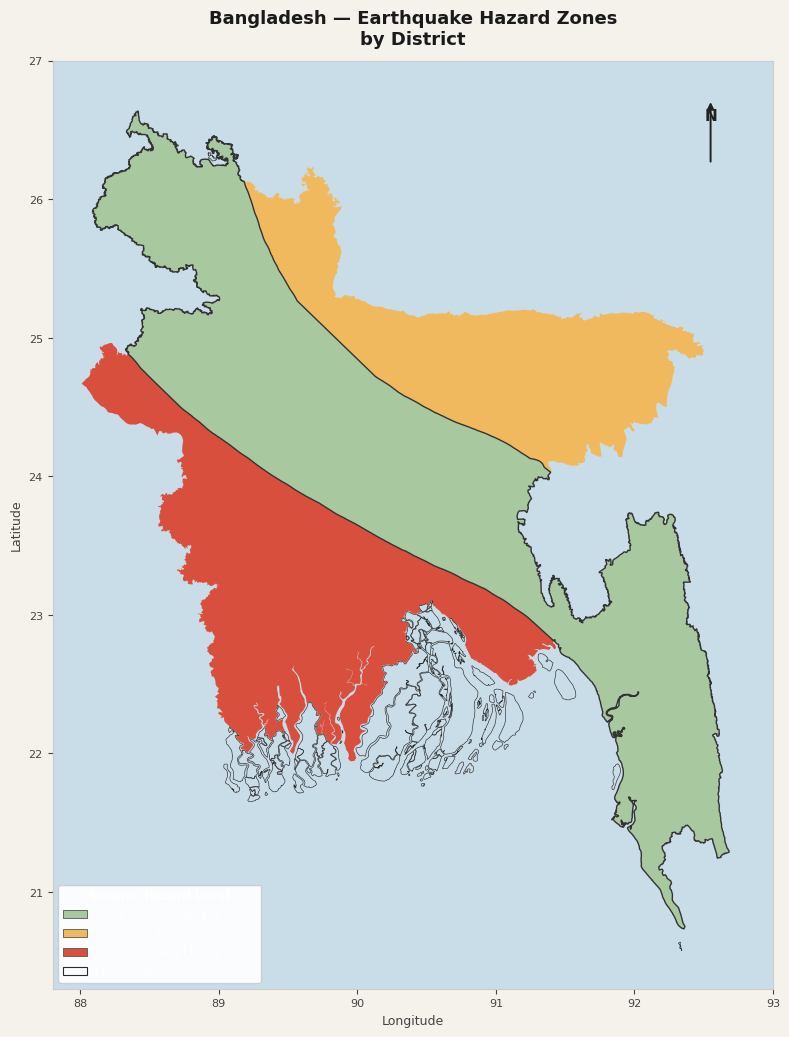

In [8]:
import struct
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection

SHP_FILE = "../data/bgd_nhr_earthquake_sparsso.shp"

# ── Parse shapefile ───────────────────────────────────────────────────────────
def parse_shp(path):
    records = []
    with open(path, "rb") as f:
        f.read(100)
        while True:
            rec_hdr = f.read(8)
            if len(rec_hdr) < 8:
                break
            content_len = struct.unpack(">i", rec_hdr[4:8])[0]
            content = f.read(content_len * 2)
            if len(content) < content_len * 2:
                break
            shp_type = struct.unpack("<i", content[0:4])[0]
            if shp_type != 5:
                continue
            bbox = struct.unpack("<4d", content[4:36])
            num_parts  = struct.unpack("<i", content[36:40])[0]
            num_points = struct.unpack("<i", content[40:44])[0]
            parts = list(struct.unpack(f"<{num_parts}i", content[44:44+num_parts*4]))
            pts_offset = 44 + num_parts * 4
            pts = [struct.unpack("<2d", content[pts_offset + i*16: pts_offset + i*16+16])
                   for i in range(num_points)]
            parts.append(num_points)
            rings = [np.array(pts[parts[p]:parts[p+1]]) for p in range(num_parts)]
            area = (bbox[2]-bbox[0]) * (bbox[3]-bbox[1])
            records.append({"rings": rings, "area": area, "bbox": bbox})
    return records

records = parse_shp(SHP_FILE)

# File structure (confirmed by inspection):
#   Record 0  → Zone I   (whole Bangladesh outline, area=27.1)  — Low hazard
#   Record 2  → Zone II  (NE region, area=7.3)                  — Moderate hazard
#   Record 3  → Zone III (NW diagonal belt, area=10.3)          — High hazard
#   All others → district / sub-district outlines
zone_low    = records[0]   # largest — drawn first as base
zone_medium = records[2]   # NE — drawn second
zone_high   = records[3]   # NW diagonal — drawn third (on top)
districts   = [r for i, r in enumerate(records) if i not in (0, 2, 3)]

# Hazard colours  (low → high)
C_LOW    = "#a8c8a0"   # soft green
C_MED    = "#f0b95e"   # amber
C_HIGH   = "#d94f3d"   # red
C_SEA    = "#c9dde8"   # light blue sea

# ── Figure ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 11), facecolor="#f5f2ec")
ax.set_facecolor(C_SEA)

# 1. Zone I  — low hazard fill (whole country base)
for ring in zone_low["rings"]:
    ax.add_patch(MplPolygon(ring, closed=True,
                            facecolor=C_LOW, edgecolor="none", zorder=2))

# 2. Zone II — moderate hazard (NE band on top of low)
for ring in zone_medium["rings"]:
    ax.add_patch(MplPolygon(ring, closed=True,
                            facecolor=C_MED, edgecolor="none", zorder=3))

# 3. Zone III — high hazard (NW diagonal, on top of both)
for ring in zone_high["rings"]:
    ax.add_patch(MplPolygon(ring, closed=True,
                            facecolor=C_HIGH, edgecolor="none", zorder=4))

# 4. District outlines on top of everything
for dist in districts:
    for ring in dist["rings"]:
        ax.add_patch(MplPolygon(ring, closed=True,
                                facecolor="none",
                                edgecolor="#2a2a2a", linewidth=0.45, zorder=5))

# 5. Outer country border (re-draw zone I outline as country edge)
for ring in zone_low["rings"]:
    ax.add_patch(MplPolygon(ring, closed=True,
                            facecolor="none",
                            edgecolor="#333333", linewidth=1.0, zorder=6))

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xlim(87.8, 93.0)
ax.set_ylim(20.3, 27.0)
ax.set_aspect("equal")
ax.set_xlabel("Longitude", fontsize=9, color="#444")
ax.set_ylabel("Latitude",  fontsize=9, color="#444")
ax.tick_params(labelsize=8, colors="#444")
for spine in ax.spines.values():
    spine.set_edgecolor("#cccccc")

ax.set_title("Bangladesh — Earthquake Hazard Zones\nby District",
             fontsize=13, fontweight="bold", color="#1a1a1a", pad=12)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(facecolor=C_LOW,  edgecolor="#555", linewidth=0.6, label="Zone I — Low hazard"),
    mpatches.Patch(facecolor=C_MED,  edgecolor="#555", linewidth=0.6, label="Zone II — Moderate hazard"),
    mpatches.Patch(facecolor=C_HIGH, edgecolor="#555", linewidth=0.6, label="Zone III — High hazard"),
    mpatches.Patch(facecolor="none", edgecolor="#2a2a2a", linewidth=0.8, label="District boundaries"),
]
legend = ax.legend(handles=legend_handles, loc="lower left",
                   framealpha=0.92, facecolor="white", edgecolor="#cccccc",
                   fontsize=8.5, title="Seismic Hazard Level", title_fontsize=8.5)
legend.get_title().set_fontweight("bold")

# ── North arrow ───────────────────────────────────────────────────────────────
ax.annotate("N", xy=(92.55, 26.55), fontsize=11, ha="center", va="bottom",
            fontweight="bold", color="#222")
ax.annotate("", xy=(92.55, 26.72), xytext=(92.55, 26.25),
            arrowprops=dict(arrowstyle="-|>", color="#222", lw=1.4))

plt.tight_layout()
out = "../data/bangladesh_earthquake_map.png"
plt.savefig(out, dpi=180, bbox_inches="tight", facecolor="#f5f2ec")
print(f"Saved → {out}")
#plt.close()